# Week 13: Designing and Building AI Agents

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Architectures, tools, multi-agent systems, evaluation, and deployment*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(13)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- decide whether a task needs one model call, a workflow, a bounded agent, or multiple agents;
- apply prompt chaining, routing, parallelization, orchestrator-workers, and evaluator-optimizer patterns;
- define task contracts, state machines, typed tools, normalized observations, and stopping rules;
- implement bounded execution with approval gates, retries, idempotency, and traces;
- design multi-agent roles and evidence-bearing communication protocols;
- evaluate architectures on a cost-quality-risk frontier;
- plan gradual deployment for scientific computing and industrial systems.

## 1. Agent engineering is interface engineering

An operational agent must determine what information to use, which action to select, whether execution succeeded, when to revise, and when to stop. The central proposition is:

$$
\text{reliable agent behavior}
=\text{clear interfaces}+\text{bounded authority}+\text{observable feedback}.
$$

Begin with a task contract:

| Field | Required specification |
|---|---|
| objective | observable outcome, not a slogan |
| acceptance evidence | tests, measurements, reviewer criteria |
| inputs and authority | authoritative data and permitted reads |
| actions | schemas, side effects, permissions, reversibility |
| budgets | time, calls, compute, money, risk |
| termination | finish, abort, escalate, approval |
| ownership | accountable person or system |

## 2. Workflow or agent?

A workflow follows a developer-defined control graph. An agent lets a model choose the next step within an action boundary. Use agentic control only when the path is genuinely uncertain and feedback can guide progress.

| Task property | Preferred starting point |
|---|---|
| one stable transformation | model call |
| known sequence with clear checks | prompt chain or deterministic workflow |
| heterogeneous requests | router plus specialist workflows |
| independent subtasks | parallel workers |
| quality can be iteratively scored | evaluator-optimizer |
| next step depends on unpredictable observations | bounded agent |
| dynamic decomposition with genuine specialization | orchestrator-workers |

Choose the least complex architecture that passes a representative evaluation.

### Core patterns from production agent design

1. **Prompt chaining:** narrow stages with validation gates.
2. **Routing:** classify a request and select an appropriate specialist.
3. **Parallelization:** divide independent sections or obtain diverse reviews.
4. **Orchestrator-workers:** dynamically create and aggregate subtasks.
5. **Evaluator-optimizer:** generate, evaluate against explicit criteria, revise.
6. **Autonomous agent:** repeatedly select tools based on environmental feedback.

These patterns compose. A deterministic outer workflow can contain one bounded agentic stage and a mandatory independent validator.

## 3. Complexity must earn its place

Let $S$ be task success, $C$ cost, $L$ latency, and $R$ operational risk. One design objective is

$$
U=S-\lambda_C C-\lambda_L L-\lambda_R R.
$$

The weights are domain decisions. In a laboratory or grid-control system, risk may dominate a modest gain in average completion. The following synthetic experiment illustrates why architecture choice should depend on task ambiguity.

In [2]:
ambiguity=np.linspace(0,1,160)
architecture_names=np.array(["fixed workflow","bounded agent","multi-agent team"])
success_curves={
    "fixed workflow":.97-.52*ambiguity**1.3,
    "bounded agent":.79+.13*ambiguity-.06*ambiguity**2,
    "multi-agent team":.78+.19*ambiguity-.04*ambiguity**2,
}
architecture_cost={"fixed workflow":.10,"bounded agent":.38,"multi-agent team":.82}
architecture_risk={"fixed workflow":.01,"bounded agent":.035,"multi-agent team":.055}
utility_curves={name:success_curves[name]-.17*architecture_cost[name]-.8*architecture_risk[name]
                for name in architecture_names}
selected_architecture=np.array([architecture_names[np.argmax([utility_curves[n][i] for n in architecture_names])]
                                for i in range(len(ambiguity))])
change_points=[ambiguity[i] for i in range(1,len(ambiguity))
               if selected_architecture[i]!=selected_architecture[i-1]]
print("utility-optimal architecture changes near ambiguity:",np.round(change_points,3))

utility-optimal architecture changes near ambiguity: [0.478]


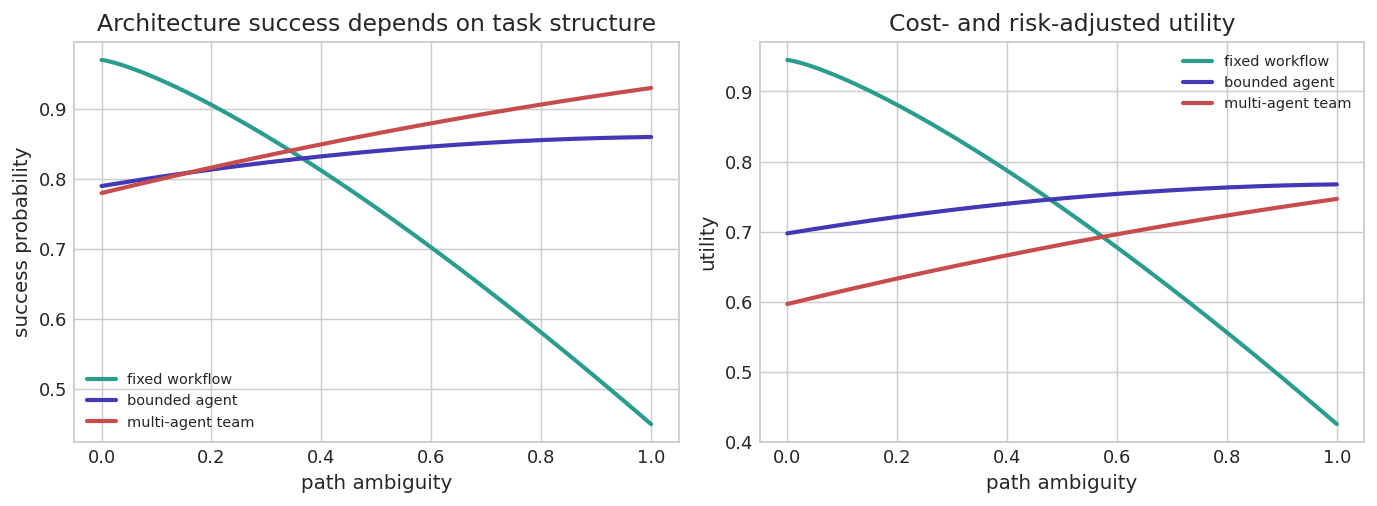

In [3]:
fig,axes=plt.subplots(1,2,figsize=(10.7,4.0))
colors_arch={"fixed workflow":UIO_GREEN,"bounded agent":UIO_PURPLE,"multi-agent team":UIO_RED}
for name in architecture_names:
    axes[0].plot(ambiguity,success_curves[name],lw=2.3,color=colors_arch[name],label=name)
axes[0].set(title="Architecture success depends on task structure",xlabel="path ambiguity",ylabel="success probability")
axes[0].legend(fontsize=8)
for name in architecture_names:
    axes[1].plot(ambiguity,utility_curves[name],lw=2.3,color=colors_arch[name],label=name)
axes[1].set(title="Cost- and risk-adjusted utility",xlabel="path ambiguity",ylabel="utility")
axes[1].legend(fontsize=8)
plt.tight_layout();plt.show()

The curves are illustrative, but the experimental principle is real: collect tasks spanning ambiguity and evaluate architectures under identical tools, models, budgets, and graders.

## 4. Represent control flow explicitly

The unit of behavior is a trajectory

$$
\tau=(s_0,d_0,a_0,o_1,s_1,\ldots,s_T),
$$

where $d_t$ is a structured decision and $o_{t+1}$ is a normalized observation. Useful controller states include

`ASSEMBLE_CONTEXT`, `PLAN`, `SELECT_ACTION`, `AWAIT_APPROVAL`, `EXECUTE`, `VERIFY`, `REPLAN`, `FINISH`, `ABORT`, and `ESCALATE`.

Explicit states make invalid transitions, budget exhaustion, and missing evidence observable.

## 5. Typed tools across a stochastic boundary

The model caller is stochastic; tool behavior should be as deterministic and inspectable as possible. A tool contract specifies types, ranges, units, preconditions, outputs, side effects, errors, timeout behavior, idempotency, and permissions.

In [4]:
@dataclass
class ToolContract:
    name:str
    required:tuple
    ranges:dict=field(default_factory=dict)
    side_effects:str="none"
    approval_required:bool=False

simulate_contract=ToolContract(
    name="simulate_intervention",
    required=("intervention","horizon_minutes"),
    ranges={"horizon_minutes":(1,120)},
    side_effects="none",
)

def validate_call(contract,arguments):
    missing=[name for name in contract.required if name not in arguments]
    if missing:return {"valid":False,"error":"missing arguments","details":missing}
    for name,(lower,upper) in contract.ranges.items():
        if not lower<=arguments[name]<=upper:
            return {"valid":False,"error":"range violation","details":{name:arguments[name]}}
    return {"valid":True,"normalized":arguments}

calls=[{"intervention":"offload","horizon_minutes":20},
       {"intervention":"offload","horizon_minutes":-4},
       {"horizon_minutes":20}]
print(pd.DataFrame([validate_call(simulate_contract,item) for item in calls]).to_string(index=False))

 valid                                         normalized             error                 details
  True {'intervention': 'offload', 'horizon_minutes': 20}               NaN                     NaN
 False                                                NaN   range violation {'horizon_minutes': -4}
 False                                                NaN missing arguments          [intervention]


Tools should be designed around decisions rather than database structure. `assess_machine_risk(sensor_window, candidate_action)` is safer and more informative than exposing unrestricted tables and shell commands.

## 6. Bounded industrial agent: maintenance decision support

Consider a simulated rotating machine with high temperature and vibration. The agent may read sensors and run a digital twin without approval. It may recommend an intervention, but applying it is a consequential side effect requiring explicit authorization.

This is not a toy travel-booking task: it represents the control structure of industrial operations, where models, optimization, operational policy, and accountable human approval must remain separate.

In [5]:
machine_state={"temperature_C":92.0,"vibration":.74,"load":.91,
               "applied_intervention":None,"executed_keys":set()}
interventions={
    "increase_cooling":{"temperature_change":-17,"vibration_change":-.02,"production":1.0,"cost":.15},
    "offload_machine":{"temperature_change":-11,"vibration_change":-.27,"production":.62,"cost":.28},
    "controlled_shutdown":{"temperature_change":-34,"vibration_change":-.56,"production":0.0,"cost":.85},
}

def normalized_observation(status,data=None,error=None,provenance="simulated plant"):
    return {"status":status,"data":data,"error":error,"provenance":provenance}

def read_sensors():
    return normalized_observation("ok",{k:machine_state[k] for k in ["temperature_C","vibration","load"]})

def digital_twin(intervention,horizon_minutes=20):
    if intervention not in interventions:return normalized_observation("invalid",error="unknown intervention")
    spec=interventions[intervention]
    temperature=machine_state["temperature_C"]+spec["temperature_change"]
    vibration=machine_state["vibration"]+spec["vibration_change"]
    thermal_risk=1/(1+np.exp(-(temperature-81)/3.5))
    vibration_risk=1/(1+np.exp(-(vibration-.58)/.07))
    combined=1-(1-thermal_risk)*(1-vibration_risk)
    return normalized_observation("ok",{"intervention":intervention,"predicted_temperature":temperature,
                                        "predicted_vibration":vibration,"predicted_risk":combined,
                                        "production":spec["production"],"cost":spec["cost"],
                                        "horizon_minutes":horizon_minutes})

def apply_intervention(intervention,idempotency_key,approved=False):
    if not approved:return normalized_observation("approval_required",error="human authorization absent")
    if idempotency_key in machine_state["executed_keys"]:
        return normalized_observation("ok",{"duplicate_suppressed":True,"intervention":intervention})
    machine_state["executed_keys"].add(idempotency_key)
    machine_state["applied_intervention"]=intervention
    return normalized_observation("ok",{"applied":intervention,"duplicate_suppressed":False})

In [6]:
def run_maintenance_agent(human_approved):
    trace=[]
    sensor_obs=read_sensors();trace.append({"state":"SENSE","action":"read_sensors","observation":sensor_obs})
    simulations=[]
    for name in interventions:
        observation=digital_twin(name);simulations.append(observation["data"])
        trace.append({"state":"EVALUATE","action":f"simulate:{name}","observation":observation})
    # Operational score makes risk dominant but retains production and cost.
    for item in simulations:
        item["decision_score"]=item["predicted_risk"]+.16*(1-item["production"])+.12*item["cost"]
    choice=min(simulations,key=lambda item:item["decision_score"])["intervention"]
    trace.append({"state":"AWAIT_APPROVAL","action":f"recommend:{choice}",
                  "observation":normalized_observation("approved" if human_approved else "denied")})
    result=apply_intervention(choice,"maintenance-event-2026-08-04",approved=human_approved)
    trace.append({"state":"EXECUTE" if human_approved else "ESCALATE","action":f"apply:{choice}","observation":result})
    return trace,simulations,choice

maintenance_trace,simulation_results,maintenance_choice=run_maintenance_agent(human_approved=True)
print(pd.DataFrame([{"step":i,"state":entry["state"],"action":entry["action"],
                    "status":entry["observation"]["status"]}
                   for i,entry in enumerate(maintenance_trace)]).to_string(index=False))
print("selected intervention:",maintenance_choice)

 step          state                        action   status
    0          SENSE                  read_sensors       ok
    1       EVALUATE     simulate:increase_cooling       ok
    2       EVALUATE      simulate:offload_machine       ok
    3       EVALUATE  simulate:controlled_shutdown       ok
    4 AWAIT_APPROVAL recommend:controlled_shutdown approved
    5        EXECUTE     apply:controlled_shutdown       ok
selected intervention: controlled_shutdown


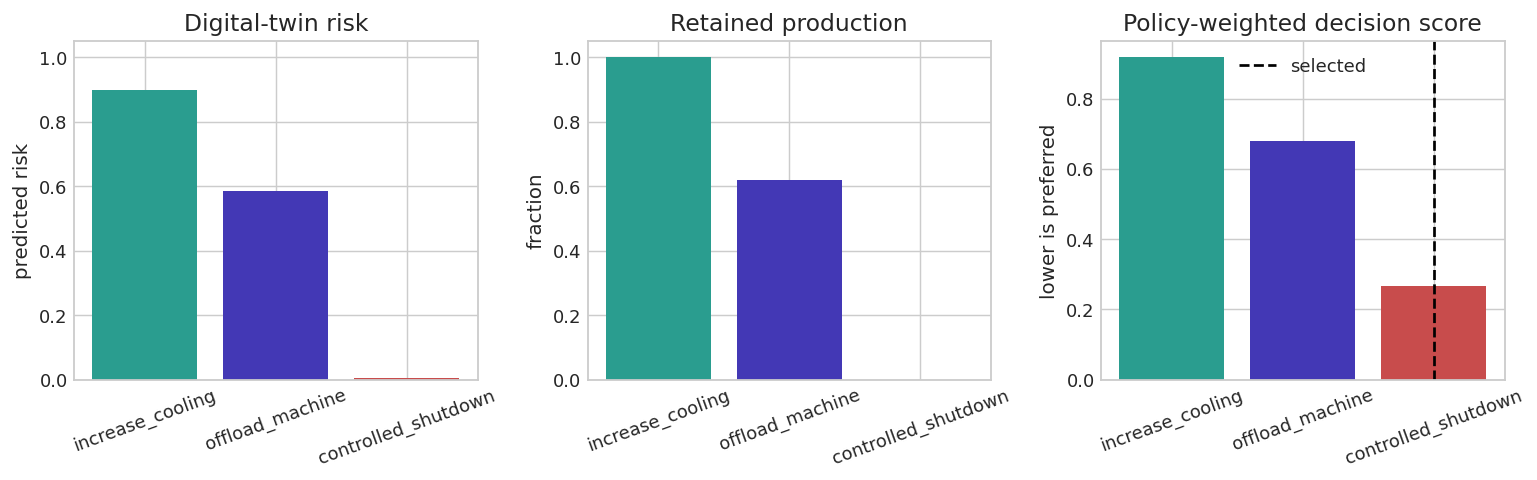

In [7]:
simulation_frame=pd.DataFrame(simulation_results).set_index("intervention")
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
axes[0].bar(simulation_frame.index,simulation_frame["predicted_risk"],color=[UIO_GREEN,UIO_PURPLE,UIO_RED])
axes[0].set(title="Digital-twin risk",ylabel="predicted risk",ylim=(0,1.05))
axes[0].tick_params(axis="x",rotation=20)
axes[1].bar(simulation_frame.index,simulation_frame["production"],color=[UIO_GREEN,UIO_PURPLE,UIO_RED])
axes[1].set(title="Retained production",ylabel="fraction",ylim=(0,1.05))
axes[1].tick_params(axis="x",rotation=20)
axes[2].bar(simulation_frame.index,simulation_frame["decision_score"],color=[UIO_GREEN,UIO_PURPLE,UIO_RED])
axes[2].axvline(list(simulation_frame.index).index(maintenance_choice),color="black",ls="--",label="selected")
axes[2].set(title="Policy-weighted decision score",ylabel="lower is preferred")
axes[2].tick_params(axis="x",rotation=20);axes[2].legend()
plt.tight_layout();plt.show()

The digital twin supplies a prediction, not authorization. Operational policy determines the score, and a human boundary controls the side effect. In production, an independent safety system would enforce hard constraints regardless of model recommendation.

## 7. Memory, context, planning, and stopping

Separate distinct forms of memory:

| Memory | Timescale | Example |
|---|---|---|
| working state | one run | plan, observations, unresolved dependencies |
| episodic | across runs | prior incidents and outcomes |
| semantic | persistent | manuals, policies, validated knowledge |
| artifact state | persistent | code, datasets, reports, job outputs |

Plans should expose assumptions, dependencies, expected observations, and revision triggers. Stop when acceptance evidence is present, the budget is exhausted, progress stalls, risk exceeds a threshold, approval is denied, or required evidence remains unavailable.

## 8. Retries, idempotency, and error classification

Errors should be classified as transient, permanent, invalid input, permission denied, or unknown. Retry only transient failures, with bounded attempts and backoff. A side-effecting action requires an idempotency key $k$ so that repeated execution has at-most-once effect.

$$
\operatorname{execute}(a,k)=
\begin{cases}
\text{stored result}, & k\text{ already completed},\\
\text{execute and store}, & \text{otherwise}.
\end{cases}
$$

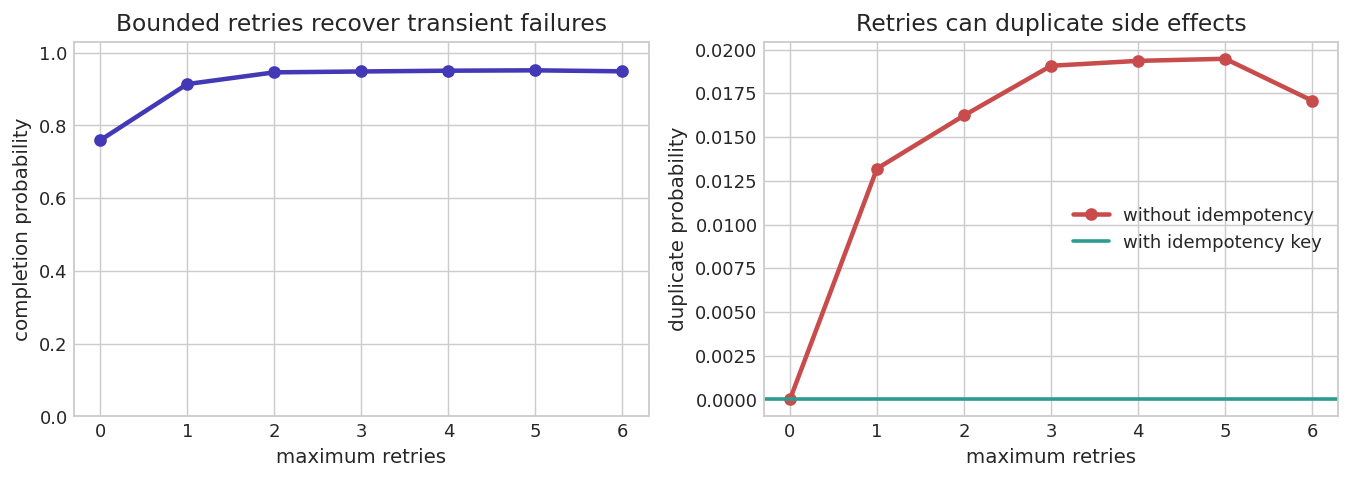

In [8]:
retry_rng=np.random.default_rng(130)
retry_counts=np.arange(0,7)
n_retry_trials=25000
success_with_retry=[];duplicate_without_idempotency=[]
for retries in retry_counts:
    successes=0;duplicates=0
    for trial in range(n_retry_trials):
        side_effect_count=0;completed=False
        for attempt in range(retries+1):
            outcome=retry_rng.choice(["ok","transient","permanent"],p=[.76,.20,.04])
            if outcome=="ok":side_effect_count+=1;completed=True;break
            if outcome=="permanent":break
            # An unknown acknowledgement can cause a duplicate side effect on retry.
            if retry_rng.random()<.08:side_effect_count+=1
        successes+=completed;duplicates+=side_effect_count>1
    success_with_retry.append(successes/n_retry_trials)
    duplicate_without_idempotency.append(duplicates/n_retry_trials)

fig,axes=plt.subplots(1,2,figsize=(10.5,3.8))
axes[0].plot(retry_counts,success_with_retry,"o-",color=UIO_PURPLE,lw=2.5)
axes[0].set(title="Bounded retries recover transient failures",xlabel="maximum retries",ylabel="completion probability",ylim=(0,1.03))
axes[1].plot(retry_counts,duplicate_without_idempotency,"o-",color=UIO_RED,lw=2.5,label="without idempotency")
axes[1].axhline(0,color=UIO_GREEN,lw=2,label="with idempotency key")
axes[1].set(title="Retries can duplicate side effects",xlabel="maximum retries",ylabel="duplicate probability")
axes[1].legend()
plt.tight_layout();plt.show()

## 9. Multi-agent systems by role and interface

Use multiple agents for context isolation, parallel search, independent evidence gathering, or heterogeneous tool permissions. Avoid them for tightly sequential reasoning where every stage depends on a shared latent state.

A role contract specifies responsibility, inputs, tools, output schema, budget, acceptance evidence, and escalation conditions. Messages should transfer claims, evidence references, uncertainty, completed artifacts, and requested actions.

Supervisor-worker is common in production; hierarchical teams manage large decompositions; a blackboard supports asynchronous specialists. Debate is a verification pattern, not a guarantee of truth.

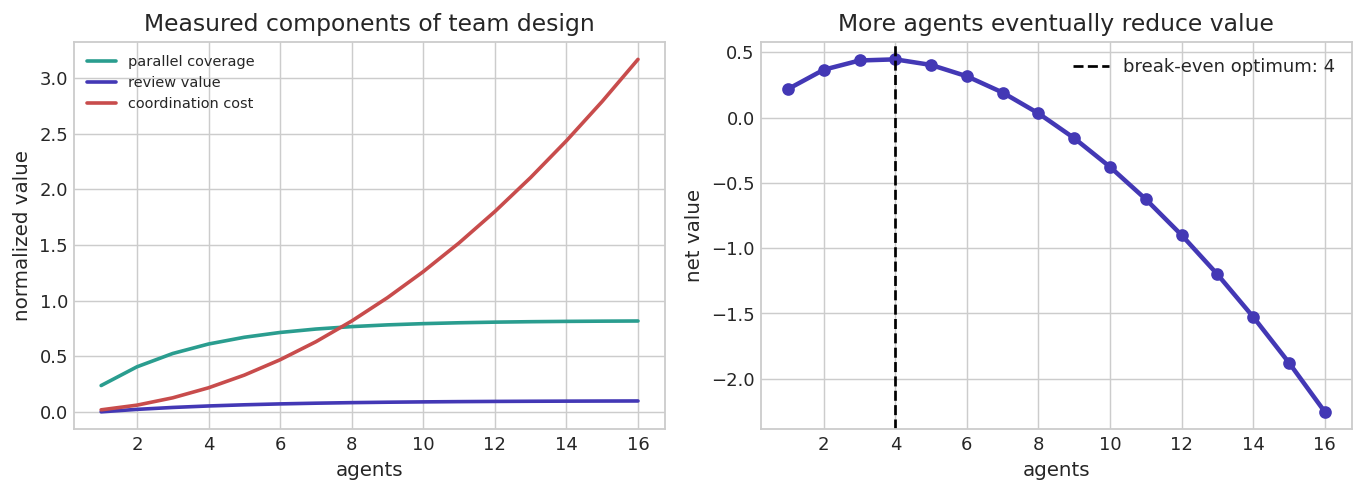

In [9]:
team_sizes=np.arange(1,17)
parallel_coverage=1-np.exp(-.34*team_sizes)
review_value=.10*(1-np.exp(-.25*np.maximum(team_sizes-1,0)))
coordination=.012*team_sizes*(team_sizes-1)+.018*team_sizes
team_value=.82*parallel_coverage+review_value-coordination
best_team=int(team_sizes[np.argmax(team_value)])
fig,axes=plt.subplots(1,2,figsize=(10.6,3.9))
axes[0].plot(team_sizes,.82*parallel_coverage,color=UIO_GREEN,lw=2,label="parallel coverage")
axes[0].plot(team_sizes,review_value,color=UIO_PURPLE,lw=2,label="review value")
axes[0].plot(team_sizes,coordination,color=UIO_RED,lw=2,label="coordination cost")
axes[0].set(title="Measured components of team design",xlabel="agents",ylabel="normalized value")
axes[0].legend(fontsize=8)
axes[1].plot(team_sizes,team_value,"o-",color=UIO_PURPLE,lw=2.5)
axes[1].axvline(best_team,color="black",ls="--",label=f"break-even optimum: {best_team}")
axes[1].set(title="More agents eventually reduce value",xlabel="agents",ylabel="net value")
axes[1].legend()
plt.tight_layout();plt.show()

## 10. Larger scientific and industrial applications

| Application | Agent roles | Authoritative evidence |
|---|---|---|
| software engineering | repository search, implementation, test, security review | build, test suite, benchmark, reviewer |
| scientific computing | algorithm design, implementation, HPC execution, numerical validation | convergence, independent code, reference data |
| data and analytics | schema agent, read-only query, computation, review | database, reconciled metric, owner approval |
| industrial operations | monitoring, digital twin, optimization, policy enforcement | sensors, constraints, operator and safety system |
| energy systems | weather/load specialist, scenario generation, dispatch optimization | grid model, feasibility, operations data |
| healthcare research | literature, cohort definition, analysis, protocol review | governed data, external validation, clinical accountability |
| cybersecurity | evidence collection, sandbox analysis, containment proposal | security policy, analyst authorization, audit trail |

These systems are valuable because they coordinate long evidence loops, not because they imitate a conversational assistant.

## 11. Evaluation and deployment

Evaluate task success, evidence correctness, robustness, cost, latency, safety violations, human effort, and reproducibility. Combine deterministic graders, domain-model graders, and human review; each has different blind spots.

Offline evaluation tests held-out tasks, perturbations, and replayed trajectories. Online monitoring measures drift, tool failures, overrides, near misses, cost, and user impact. Increase consequence gradually:

$$
\text{replay}\rightarrow\text{sandbox}\rightarrow\text{shadow}
\rightarrow\text{suggest}\rightarrow\text{bounded action}
\rightarrow\text{broader autonomy}.
$$

    architecture  success  mean cost  p95 latency  violation rate
  fixed workflow    0.756      0.102        1.943           0.009
   bounded agent    0.840      0.385        3.302           0.029
multi-agent team    0.876      0.838        5.489           0.047


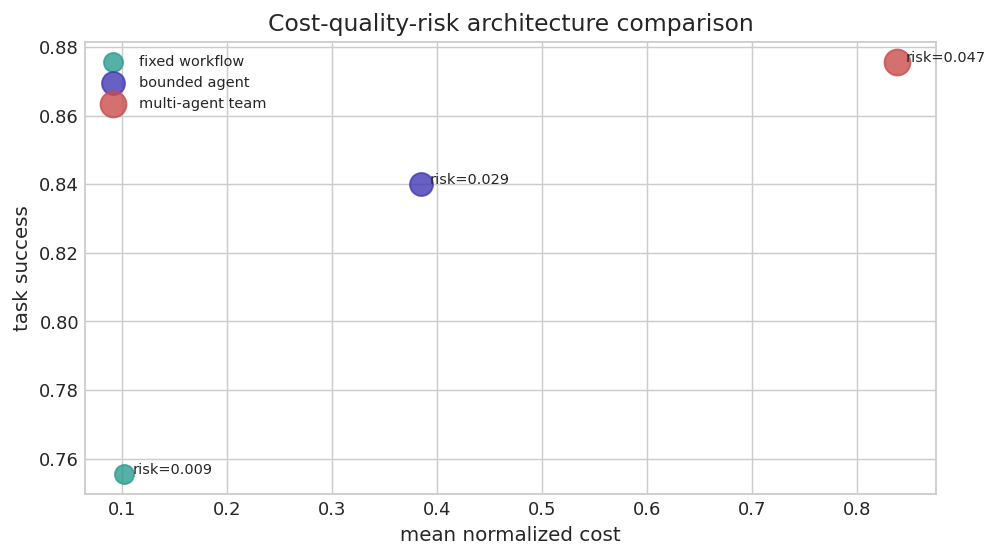

In [10]:
eval_rng=np.random.default_rng(131)
n_eval=900
task_ambiguity=eval_rng.beta(1.8,1.8,n_eval)
evaluation_rows=[]
for name in architecture_names:
    success_probability=np.interp(task_ambiguity,ambiguity,success_curves[name])
    success=eval_rng.random(n_eval)<success_probability
    cost=architecture_cost[name]*eval_rng.lognormal(0,.18,n_eval)
    latency=(1.0+3.5*architecture_cost[name])*eval_rng.lognormal(0,.22,n_eval)
    violation_probability=architecture_risk[name]*(.45+task_ambiguity)
    violations=eval_rng.random(n_eval)<violation_probability
    evaluation_rows.append({"architecture":name,"success":success.mean(),"mean cost":cost.mean(),
                            "p95 latency":np.quantile(latency,.95),"violation rate":violations.mean()})
evaluation_frame=pd.DataFrame(evaluation_rows)
print(evaluation_frame.to_string(index=False,float_format=lambda z:f"{z:.3f}"))

plt.figure(figsize=(7.8,4.4))
for _,row in evaluation_frame.iterrows():
    plt.scatter(row["mean cost"],row["success"],s=2500*row["violation rate"]+90,
                color=colors_arch[row["architecture"]],alpha=.8,label=row["architecture"])
    plt.text(row["mean cost"]+.008,row["success"],f"risk={row['violation rate']:.3f}",fontsize=8)
plt.xlabel("mean normalized cost");plt.ylabel("task success")
plt.title("Cost-quality-risk architecture comparison")
plt.legend(fontsize=8);plt.tight_layout();plt.show()

A single scalar leaderboard would hide the risk and cost trade-off. Architecture selection should use a Pareto frontier plus explicit operational constraints.

## 12. Security and observability

Security analysis follows the entire action path: untrusted input, retrieval poisoning, prompt injection, confused-deputy tool use, secret exposure, unsafe code execution, excessive permissions, and output exfiltration.

A useful trace reconstructs task version, model and prompt, selected context, structured decisions, tool arguments, normalized observations, retries, idempotency keys, approvals, artifacts, evaluator outputs, cost, and termination. Logs must protect sensitive data while remaining sufficient for diagnosis.

## Practical build sequence

1. Define the task contract and collect representative trajectories.
2. Build deterministic baselines and the smallest viable workflow.
3. Specify state, decisions, tool contracts, and execution boundary.
4. Add verifiers, budgets, stopping rules, and approval gates.
5. Instrument complete traces and deterministic component tests.
6. Introduce agentic control only where path uncertainty requires it.
7. Compare architectures under equal resources and graders.
8. Red-team tools, context, memory, and authorization paths.
9. Deploy through replay, sandbox, shadow, and bounded action.
10. Monitor drift, failures, overrides, and real user value.

## Problem set

1. Write a task contract for an HPC agent that compiles, runs, and validates a numerical simulation.
2. For each Anthropic pattern, give one task that fits and one task that does not.
3. Reweight the cost-risk utility example for a safety-critical system. How does the architecture boundary move?
4. Extend `ToolContract` with units, enumerated values, timeouts, and permission scopes.
5. Modify the maintenance agent so that high predicted risk triggers shutdown regardless of production score.
6. Simulate denial of approval and an unavailable digital twin. Verify correct escalation and no side effect.
7. Derive the completion probability after $m$ retries for independent transient failures. State why the independence assumption is weak.
8. Design an idempotency test for an experiment-submission tool.
9. Specify role and message contracts for a scientific software team with planner, numerical analyst, implementer, and verifier.
10. Construct an evaluation set that can distinguish a fixed workflow, bounded agent, and multi-agent team.

**Mini-project.** Build a production-style bounded agent for scientific computing or industrial decision support. Include typed tools, normalized observations, a state machine, retry classification, idempotency, an approval boundary, tracing, and an evaluation harness. Compare against a deterministic workflow on success, cost, latency, robustness, and violations.

## Summary

- Start from task structure and evidence requirements, not the label “agent.”
- Prompt chaining, routing, parallelization, orchestrator-workers, and evaluator-optimizer are reusable control patterns.
- Reliable single agents require explicit state, typed tools, normalized observations, stopping rules, permissions, and traces.
- Retries are safe only with error classification, bounds, and idempotency for side effects.
- Multi-agent systems justify their complexity through measured specialization or parallelism gains.
- Industrial and scientific agents coordinate models, optimization, policy, evidence, and accountable humans.
- Autonomy should increase only when trajectory-level evidence supports it.

**Further reading:** Lecture 13; Anthropic, [Building Effective Agents](https://www.anthropic.com/research/building-effective-agents); [Model Context Protocol](https://modelcontextprotocol.io/); and the Agents for Science curriculum.